# Hotel Booking Demand Analysis

## Project Objective
This project analyzes hotel booking demand data to understand cancellation behavior, seasonal demand, customer segments, booking channels, and revenue opportunities.

## Business Goal
The goal is to generate actionable insights that help hotel management improve occupancy planning, reduce cancellations, and increase revenue.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from sqlalchemy import create_engine

plt.style.use("default")
pd.set_option("display.max_columns", None)

##  Load Raw Dataset
In this step, the raw hotel booking data is loaded for initial exploration.

In [2]:
df_raw = pd.read_csv("../data/raw/hotel_bookings.csv")
df_raw.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Step 2: Explore Dataset Structure
This step helps understand the size, columns, data types, missing values, and general quality of the dataset.

In [3]:
df_raw.shape

(119390, 32)

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
df_raw.describe(include="all")

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390,118902,119390,119390,119390.000000,119390.000000,119390.000000,119390,119390,119390.000000,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,177,8,5,NaN,NaN,NaN,10,12,NaN,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB,PRT,Online TA,TA/TO,NaN,NaN,NaN,A,A,NaN,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92310,48590,56477,97870,NaN,NaN,NaN,85994,74053,NaN,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,NaN,NaN,NaN,NaN,0.031912,0.087118,0.137097,NaN,NaN,0.221124,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,NaN,NaN,NaN,NaN,0.175767,0.844336,1.497437,NaN,NaN,0.652306,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


In [6]:
df_raw.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

In [7]:
df_raw.duplicated().sum()

np.int64(31994)

## Step 3: Define Business Questions

The analysis is guided by the following business questions:

1. Which hotel type has a higher cancellation rate?
2. How does lead time influence the probability of cancellation?
3. Which months or seasons have the highest booking demand and revenue potential?
4. Which customer segments or booking channels contribute the most bookings and revenue?
5. What factors are associated with higher ADR and longer stays?

## Step 4: Clean the Data
The data cleaning process includes:
- handling missing values
- removing duplicate records
- removing invalid guest records
- creating a proper arrival date
- engineering business-related features

In [8]:
df = df_raw.copy()

In [9]:
# Fill missing values
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)

In [10]:
# Remove duplicates
df = df.drop_duplicates().copy()

In [11]:
# Remove rows with zero guests
df = df[
    ~((df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0))
].copy()

In [12]:
# Create month mapping
month_map = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12
}

df["arrival_month_num"] = df["arrival_date_month"].map(month_map)

In [13]:
# Create proper date column
df["arrival_date"] = pd.to_datetime(
    dict(
        year=df["arrival_date_year"],
        month=df["arrival_month_num"],
        day=df["arrival_date_day_of_month"]
    ),
    errors="coerce"
)

In [14]:
# Create engineered features
df["total_nights"] = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["estimated_revenue"] = df["adr"] * df["total_nights"]
df["is_family"] = ((df["children"] + df["babies"]) > 0).astype(int)

In [15]:
def get_season(month):
    if month in ["December", "January", "February"]:
        return "Winter"
    if month in ["March", "April", "May"]:
        return "Spring"
    if month in ["June", "July", "August"]:
        return "Summer"
    return "Autumn"

df["arrival_season"] = df["arrival_date_month"].apply(get_season)

In [16]:
def lead_time_group(days):
    if days <= 30:
        return "0-30 days"
    if days <= 90:
        return "31-90 days"
    if days <= 180:
        return "91-180 days"
    return "180+ days"

df["lead_time_group"] = df["lead_time"].apply(lead_time_group)

In [17]:
df.shape

(87230, 40)

### Cleaning Summary
After cleaning, the dataset is more reliable for business analysis. Missing values have been handled, duplicate records were removed, invalid guest rows were filtered out, and new business-relevant features were created.

## Step 5: Save Cleaned Dataset
The cleaned dataset is saved separately so that the raw file remains unchanged and the cleaned version can be reused for analysis.

In [20]:
df.to_csv("../data/cleaned/cleaned_hotel_bookings.csv", index=False)

In [21]:
df = pd.read_csv("../data/cleaned/cleaned_hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_month_num,arrival_date,total_nights,total_guests,estimated_revenue,is_family,arrival_season,lead_time_group
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,7,2015-07-01,0,2.0,0.0,0,Summer,180+ days
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,7,2015-07-01,0,2.0,0.0,0,Summer,180+ days
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,7,2015-07-01,1,1.0,75.0,0,Summer,0-30 days
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,7,2015-07-01,1,1.0,75.0,0,Summer,0-30 days
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03,7,2015-07-01,2,2.0,196.0,0,Summer,0-30 days


## Step 6: Load Data into SQLite Database
This step allows SQL analysis on the cleaned dataset.

In [22]:
engine = create_engine("sqlite:///../data/hotel_bookings.db")
df.to_sql("hotel_bookings", con=engine, if_exists="replace", index=False)

87230

## Business Question 1: Which hotel type has a higher cancellation rate?

In [23]:
query_1 = """
SELECT
    hotel,
    COUNT(*) AS total_bookings,
    SUM(is_canceled) AS total_cancellations,
    ROUND(SUM(is_canceled) * 100.0 / COUNT(*), 2) AS cancellation_rate_pct
FROM hotel_bookings
GROUP BY hotel;
"""

pd.read_sql(query_1, engine)

,hotel,total_bookings,total_cancellations,cancellation_rate_pct
0,City Hotel,53274,16035,30.10
1,Resort Hotel,33956,7974,23.48


### Interpretation
This query compares booking volume and cancellation rate across hotel types. A higher cancellation rate indicates greater booking instability and can affect room planning and revenue forecasting.

## Business Question 2: How does lead time influence cancellation probability?

In [24]:
query_2 = """
SELECT
    CASE
        WHEN lead_time <= 30 THEN '0-30 days'
        WHEN lead_time <= 90 THEN '31-90 days'
        WHEN lead_time <= 180 THEN '91-180 days'
        ELSE '180+ days'
    END AS lead_time_group,
    COUNT(*) AS total_bookings,
    SUM(is_canceled) AS total_cancellations,
    ROUND(SUM(is_canceled) * 100.0 / COUNT(*), 2) AS cancellation_rate_pct
FROM hotel_bookings
GROUP BY lead_time_group
ORDER BY cancellation_rate_pct DESC;
"""

pd.read_sql(query_2, engine)

,lead_time_group,total_bookings,total_cancellations,cancellation_rate_pct
0,180+ days,11757,4672,39.74
1,91-180 days,18224,6380,35.01
2,31-90 days,22720,7280,32.04
3,0-30 days,34529,5677,16.44


### Interpretation
This query helps identify whether early bookings are more likely to be canceled. If longer lead times show higher cancellation rates, the hotel may consider stricter cancellation policies for such bookings.

## Business Question 3: Which months or years have the highest demand and revenue potential?

In [ ]:
query_3 = """
SELECT
    arrival_date_year,
    arrival_date_month,
    COUNT(*) AS total_bookings,
    ROUND(AVG(adr), 2) AS avg_adr,
    ROUND(SUM(adr * (stays_in_week_nights + stays_in_weekend_nights)), 2) AS estimated_revenue
FROM hotel_bookings
GROUP BY arrival_date_year, arrival_date_month
ORDER BY arrival_date_year, total_bookings DESC;
"""

pd.read_sql(query_3, engine).head(15)

## Business Question 4: Which market segments contribute the most bookings and revenue?

In [25]:
query_4 = """
SELECT
    market_segment,
    COUNT(*) AS total_bookings,
    ROUND(AVG(adr), 2) AS avg_adr,
    ROUND(SUM(adr * (stays_in_week_nights + stays_in_weekend_nights)), 2) AS estimated_revenue,
    ROUND(SUM(is_canceled) * 100.0 / COUNT(*), 2) AS cancellation_rate_pct
FROM hotel_bookings
GROUP BY market_segment
ORDER BY estimated_revenue DESC;
"""

pd.read_sql(query_4, engine)

,market_segment,total_bookings,avg_adr,estimated_revenue,cancellation_rate_pct
0,Online TA,51553,118.30,22259326.55,35.38
1,Offline TA/TO,13855,81.95,5416464.95,14.85
2,Direct,11780,116.78,4855042.75,14.75
3,Groups,4922,75.17,1238456.92,27.06
4,Corporate,4200,68.34,594144.08,12.12
5,Aviation,226,100.61,83033.36,19.91
6,Complementary,692,3.09,5074.52,12.28
7,Undefined,2,15.00,48.00,100.00


## Business Question 5: Which booking channels bring the most stable bookings?

In [26]:
query_5 = """
SELECT
    distribution_channel,
    COUNT(*) AS total_bookings,
    ROUND(AVG(adr), 2) AS avg_adr,
    ROUND(SUM(is_canceled) * 100.0 / COUNT(*), 2) AS cancellation_rate_pct
FROM hotel_bookings
GROUP BY distribution_channel
ORDER BY total_bookings DESC;
"""

pd.read_sql(query_5, engine)

,distribution_channel,total_bookings,avg_adr,cancellation_rate_pct
0,TA/TO,69028,108.72,31.00
1,Direct,12954,109.39,14.84
2,Corporate,5062,68.77,12.76
3,GDS,181,120.32,19.89
4,Undefined,5,46.24,80.00


## Visualization 1: Booking Distribution by Hotel Type

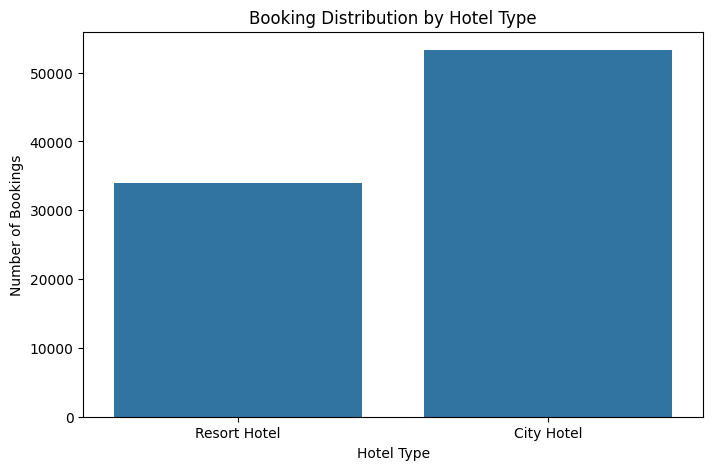

In [58]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="hotel")
plt.title("Booking Distribution by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.savefig("../visuals/booking_distribution_by_hotel .png", bbox_inches="tight")
plt.show()

### Interpretation
This chart shows the distribution of bookings between City Hotel and Resort Hotel. It helps identify which hotel type receives more booking demand overall.

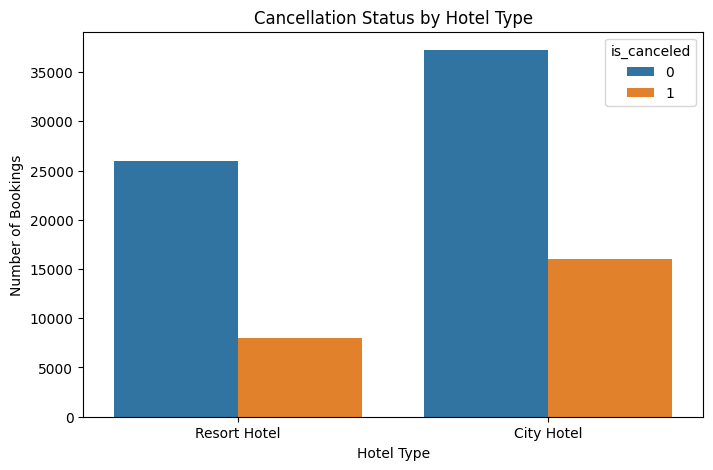

In [28]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="hotel", hue="is_canceled")
plt.title("Cancellation Status by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.show()

### Interpretation
This chart compares canceled and non-canceled bookings for each hotel type. It helps reveal which hotel type experiences more booking instability.

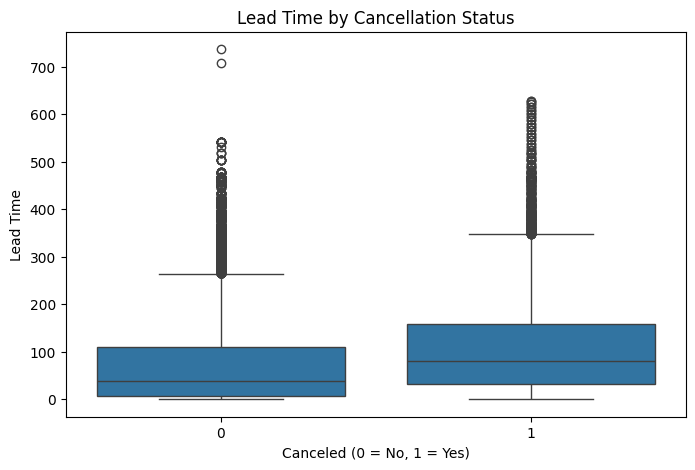

In [57]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_canceled", y="lead_time")
plt.title("Lead Time by Cancellation Status")
plt.xlabel("Canceled (0 = No, 1 = Yes)")
plt.ylabel("Lead Time")
plt.savefig("../visuals/lead_time_cancellation .png", bbox_inches="tight")
plt.show()

### Interpretation
This plot helps assess whether canceled bookings tend to have longer lead times. A higher median lead time for canceled bookings suggests increased uncertainty in early bookings.

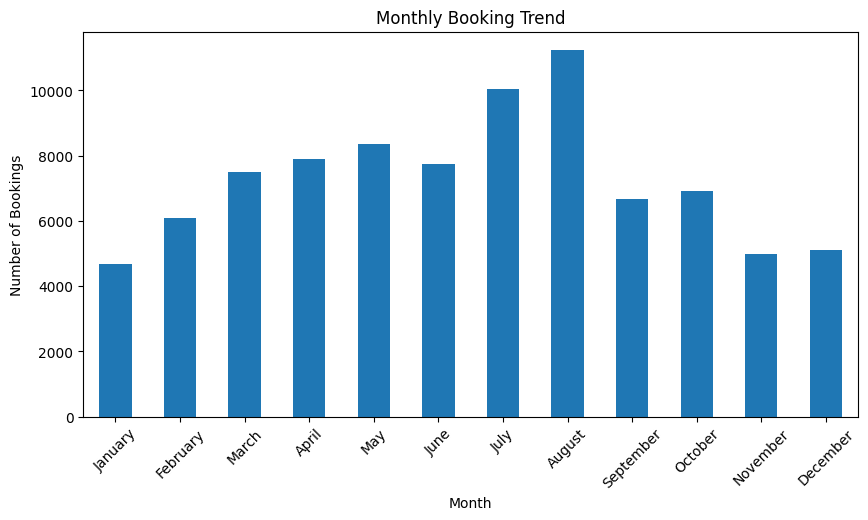

In [56]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_bookings = (
    df["arrival_date_month"]
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(10, 5))
monthly_bookings.plot(kind="bar")
plt.title("Monthly Booking Trend")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.savefig("../visuals/monthly_booking_trend .png", bbox_inches="tight")
plt.show()

### Interpretation
This chart shows seasonal booking demand across months. It helps identify peak and low-demand periods for staffing and pricing decisions.

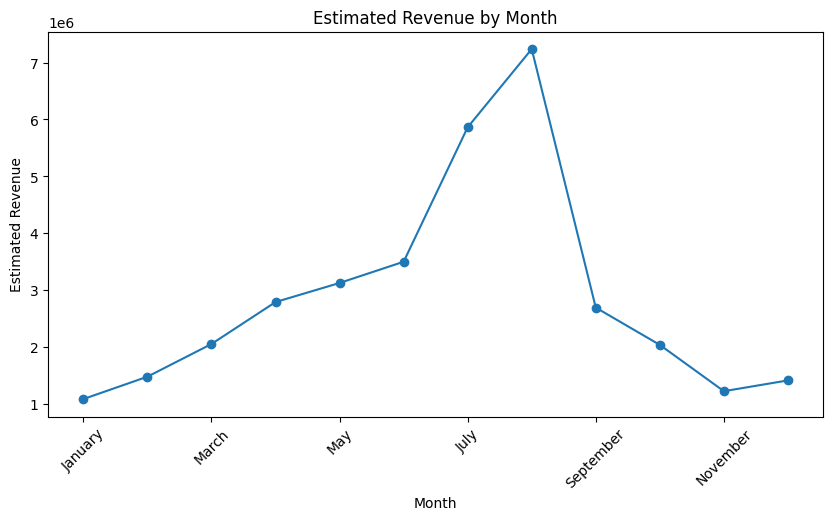

In [55]:
revenue_by_month = (
    df.groupby("arrival_date_month")["estimated_revenue"]
    .sum()
    .reindex(month_order)
)

plt.figure(figsize=(10, 5))
revenue_by_month.plot(kind="line", marker="o")
plt.title("Estimated Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Estimated Revenue")
plt.savefig("../visuals/revenue_by_month .png", bbox_inches="tight")
plt.xticks(rotation=45)
plt.show()

### Interpretation
This chart tracks estimated revenue across months. It helps the hotel identify periods with stronger revenue potential and plan promotions or pricing strategies accordingly.

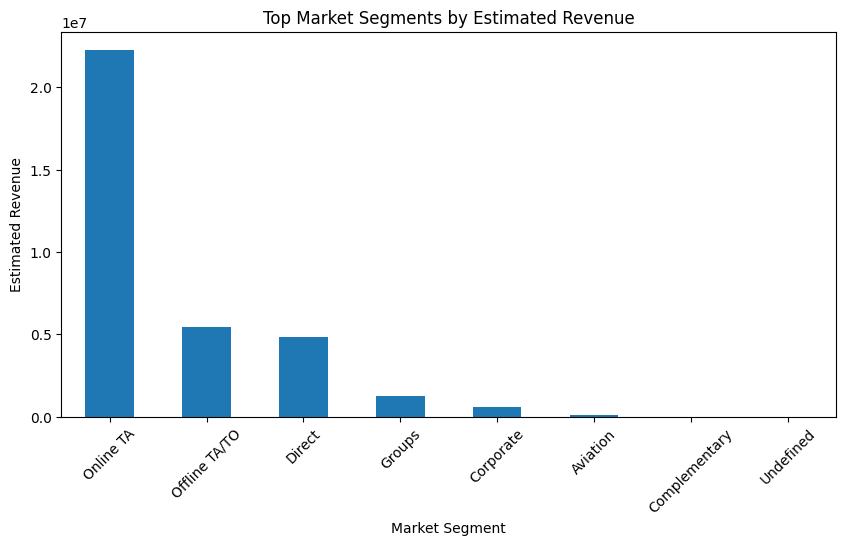

In [32]:
segment_revenue = (
    df.groupby("market_segment")["estimated_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
segment_revenue.plot(kind="bar")
plt.title("Top Market Segments by Estimated Revenue")
plt.xlabel("Market Segment")
plt.ylabel("Estimated Revenue")
plt.xticks(rotation=45)
plt.show()

### Interpretation
This chart shows which customer market segments contribute the highest estimated revenue. It helps management identify the most valuable customer groups.

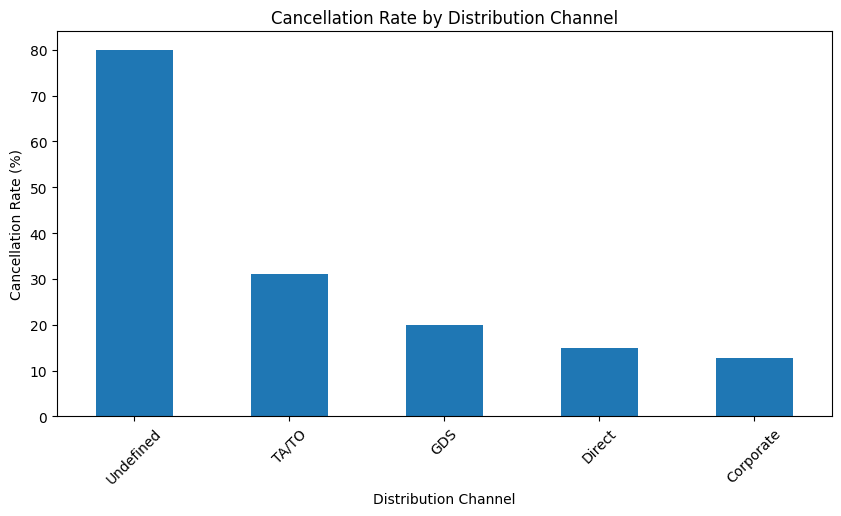

In [54]:
channel_cancel = (
    df.groupby("distribution_channel")["is_canceled"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10, 5))
channel_cancel.plot(kind="bar")
plt.title("Cancellation Rate by Distribution Channel")
plt.xlabel("Distribution Channel")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.savefig("../visuals/cancellation_by_distribution_channel .png", bbox_inches="tight")
plt.show()

### Interpretation
This chart compares cancellation rate across booking channels. It helps evaluate which channels provide more reliable bookings.

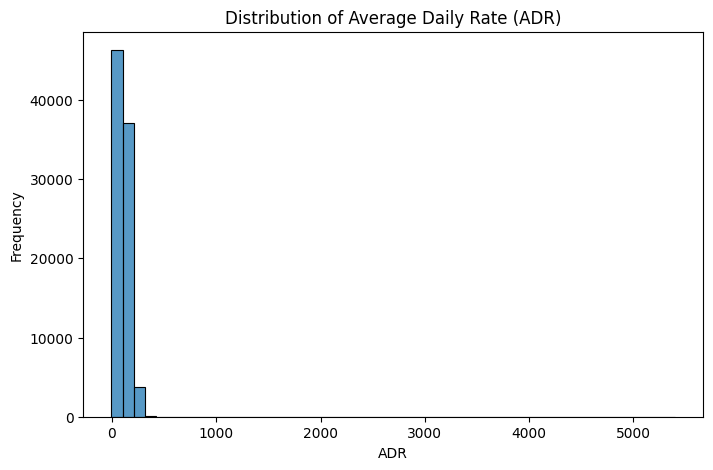

In [52]:
plt.figure(figsize=(8, 5))
sns.histplot(df["adr"], bins=50)
plt.title("Distribution of Average Daily Rate (ADR)")
plt.xlabel("ADR")
plt.ylabel("Frequency")
plt.savefig("../visuals/distribution_of_adr .png", bbox_inches="tight")
plt.show()

### Interpretation
This distribution shows how room rates vary across bookings. It helps understand common pricing levels and detect possible outliers.

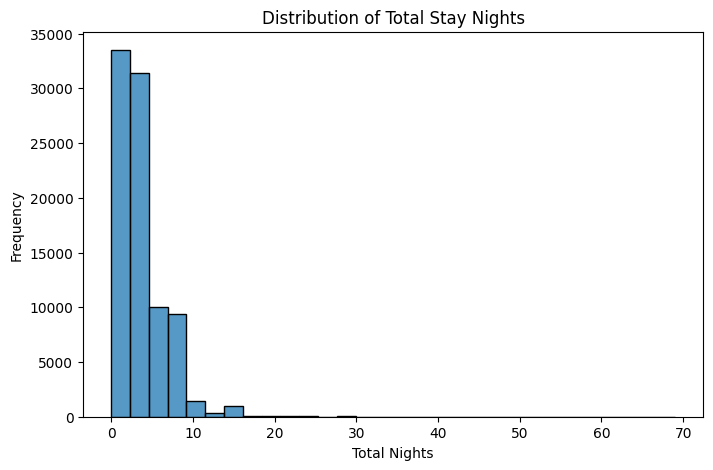

In [35]:
plt.figure(figsize=(8, 5))
sns.histplot(df["total_nights"], bins=30)
plt.title("Distribution of Total Stay Nights")
plt.xlabel("Total Nights")
plt.ylabel("Frequency")
plt.show()

### Interpretation
This chart shows the most common booking lengths. It helps understand customer stay behavior and package planning opportunities.

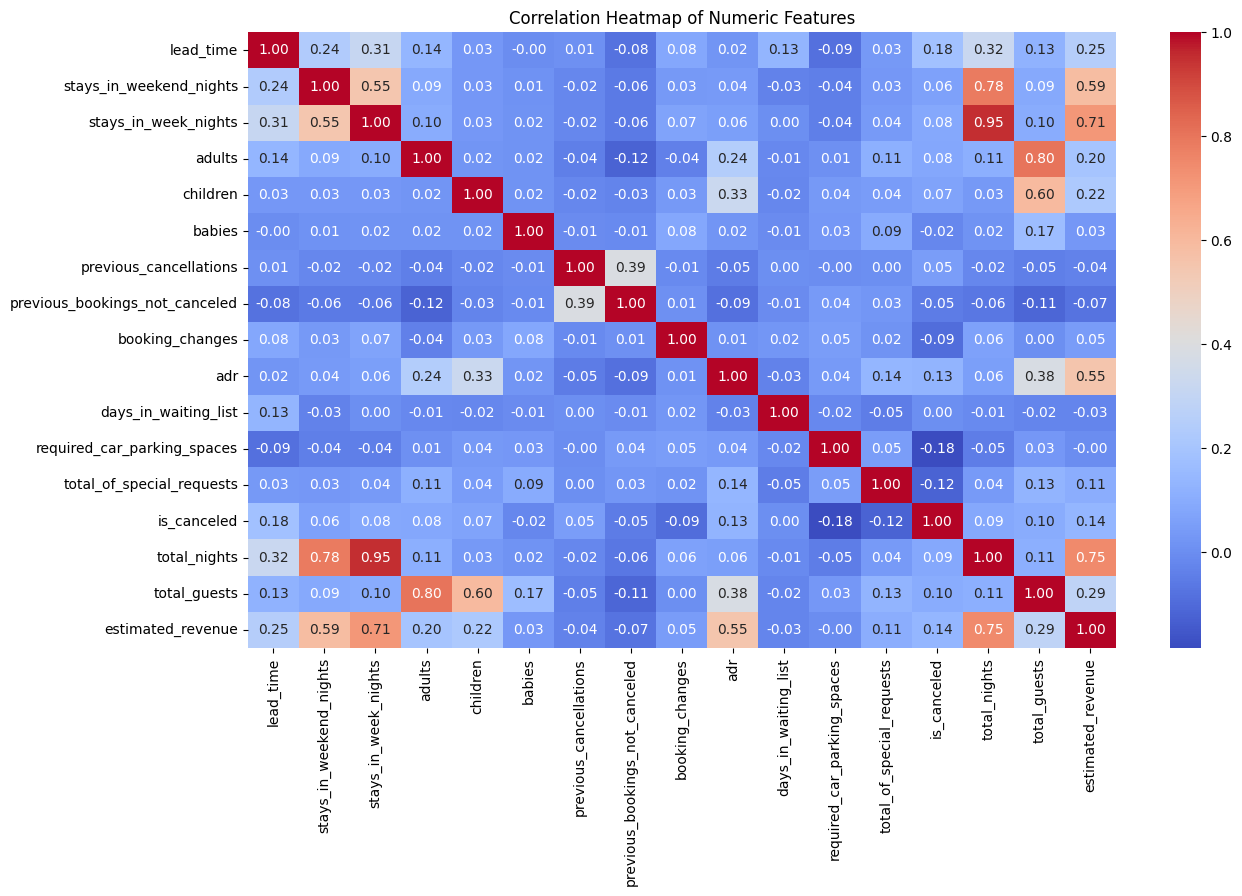

In [50]:
numeric_cols = [
    "lead_time", "stays_in_weekend_nights", "stays_in_week_nights",
    "adults", "children", "babies", "previous_cancellations",
    "previous_bookings_not_canceled", "booking_changes", "adr",
    "days_in_waiting_list", "required_car_parking_spaces",
    "total_of_special_requests", "is_canceled", "total_nights",
    "total_guests", "estimated_revenue"
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.savefig("../visuals/behavior .png", bbox_inches="tight")
plt.show()

### Interpretation
The heatmap provides a broad view of linear relationships among numeric variables. It helps identify factors associated with cancellation, revenue, and booking behavior.

## Statistical Testing
Statistical tests are used to validate whether observed differences are meaningful and not due to random variation.

In [37]:
city_adr = df[df["hotel"] == "City Hotel"]["adr"]
resort_adr = df[df["hotel"] == "Resort Hotel"]["adr"]

t_stat_adr, p_value_adr = ttest_ind(city_adr, resort_adr, equal_var=False)

print("T-statistic:", t_stat_adr)
print("P-value:", p_value_adr)

T-statistic: 30.287459634474907
P-value: 6.153245924852694e-200


### Interpretation
This test checks whether average daily rates differ significantly between City Hotel and Resort Hotel. A very small p-value suggests the difference is statistically significant.

In [38]:
cancelled_lead = df[df["is_canceled"] == 1]["lead_time"]
not_cancelled_lead = df[df["is_canceled"] == 0]["lead_time"]

t_stat_lead, p_value_lead = ttest_ind(cancelled_lead, not_cancelled_lead, equal_var=False)

print("T-statistic:", t_stat_lead)
print("P-value:", p_value_lead)

T-statistic: 52.60200304391143
P-value: 0.0


### Interpretation
This test checks whether lead time differs significantly between canceled and non-canceled bookings. If the p-value is very low, it supports the idea that lead time is related to cancellation behavior.

## Key Findings

1. Cancellation rates differ across hotel types, indicating varying booking stability.
2. Longer lead times are associated with higher cancellation risk.
3. Booking demand and estimated revenue vary by month, showing clear seasonality.
4. Some market segments contribute disproportionately to revenue.
5. Distribution channels differ in booking volume and cancellation quality.